In [9]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import f_classif

In [3]:
df=pd.read_csv("telecom_cus.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=1000, step=1)
All columns are
0 region
1 tenure
2 age
3 marital
4 address
5 income
6 ed
7 employ
8 retire
9 gender
10 reside
11 custcat


In [4]:
df.sample(n=10)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
997,3,67,59,0,40,944,5,33,0,1,1,4
73,2,48,43,0,13,110,5,15,0,1,3,2
163,3,29,26,0,7,34,1,7,0,1,2,3
110,3,61,50,1,30,102,4,9,0,1,3,2
35,3,20,35,1,11,52,4,0,0,0,2,2
545,2,48,31,1,12,52,4,3,0,0,3,4
66,3,28,51,1,22,40,3,10,0,1,6,3
649,3,23,50,0,1,151,4,8,0,1,1,1
811,3,28,22,1,3,23,3,1,0,0,5,1
939,3,16,48,0,25,59,2,13,0,0,2,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   region   1000 non-null   int64
 1   tenure   1000 non-null   int64
 2   age      1000 non-null   int64
 3   marital  1000 non-null   int64
 4   address  1000 non-null   int64
 5   income   1000 non-null   int64
 6   ed       1000 non-null   int64
 7   employ   1000 non-null   int64
 8   retire   1000 non-null   int64
 9   gender   1000 non-null   int64
 10  reside   1000 non-null   int64
 11  custcat  1000 non-null   int64
dtypes: int64(12)
memory usage: 93.9 KB


<Axes: >

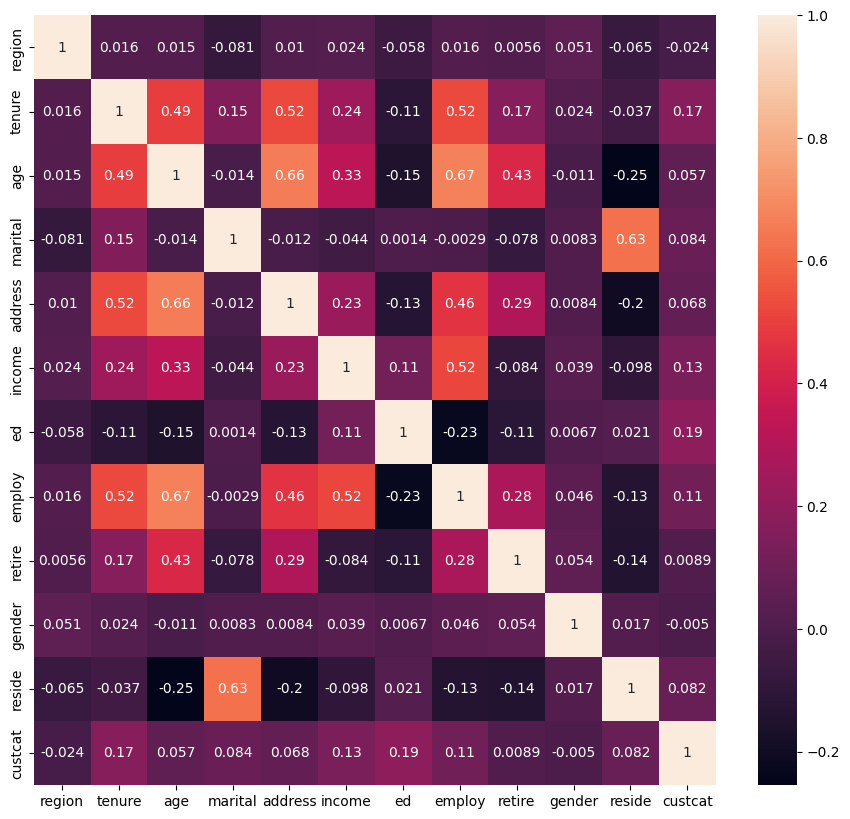

In [6]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [8]:
print('''The Heatmap may not give the best relationship between the features.
As our feature are numerical and the custcat is categorial
So the best test will be ANOVA F-Test''')

The Heatmap may not give the best relationship between the features.
As our feature are numerical and the custcat is categorial
So the best test will be ANOVA F-Test


In [10]:
# Isolating input and target
X = df.drop(columns=["custcat"])
y = df["custcat"]

In [11]:
fscores, pvalues = f_classif(X, y)

anovadf = pd.DataFrame({"Feature": X.columns,"F-Score": fscores,"p-value": pvalues})

anovadf = anovadf.sort_values(by="F-Score",ascending=False)

print(anovadf.round(4))

    Feature  F-Score  p-value
6        ed  61.4543   0.0000
1    tenure  41.3101   0.0000
7    employ  16.9757   0.0000
4   address   8.4329   0.0000
2       age   7.5214   0.0001
5    income   6.6894   0.0002
10   reside   3.9765   0.0079
3   marital   3.4995   0.0151
8    retire   3.0047   0.0296
0    region   1.0949   0.3503
9    gender   0.3730   0.7725


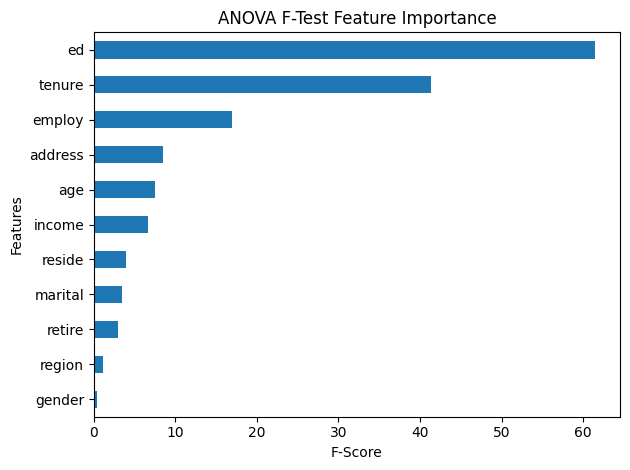

In [12]:
anovadf.sort_values("F-Score").plot(x="Feature",y="F-Score",kind="barh",legend=False)

plt.title("ANOVA F-Test Feature Importance")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [13]:
print('''The test tells us that ed and tenure column has the highest impact on custcat
region and gender have the least impact so we can safely drop them
''')

The test tells us that ed and tenure column has the highest impact on custcat
region and gender have the least impact so we can safely drop them

